<a href="https://colab.research.google.com/github/adirie3/datascience2026/blob/main/Apple_Music_Group_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Apple Music
### By Group 2 (Abshiro Abdirazak DIRIE, Lise SAMSON, Khoi Nguyen TRAN, I-Shan TU, Siyu)

## **Apple Music introduction**

---

Apple music is a **music streaming service** developed by **Apple Inc.**, one of the world's leading technology companies specializing in consumer electronics. The platform allows users to stream millions of songs on demand, create playlists and access curated content on Apple devices such as iPhone, iPad, Mac and Apple Watch.


---

***Historical context and evolution***

Apple entered the music streaming market relatively late compared to its competitors. The service was officialy launched in June 2015, following Apple's acquisition of Beats Electronics and Beats Music in 2014.
Since its launch, Apple Music has grown rapidly. In six months, it has already reached 10 million paid subscribers, demonstrating strong adoption among Apple's global user base. Over the years, the service has continued to expand internationally and now operates in more than 160 countries with tens of millions of subscribers worldwide.


---

***Scope of activity***

Apple Music operates in the music streaming industry that is part of the broader enteertainment and digital media sector.
The platform provides :

-> music on demand in streaming.

-> organizes radio stations and playlists.

-> personalized recommendations based on the user's behavior.

This business model reflects the shift from physical and digital downloads to subscription streaming, which has become the dominant form of music consumption globally.


---

***Competitive environment***

The music streaming market is very competitive. Apple Music's main competitors include :

-> Spotify

-> Amazon Music

-> Youtube Music

-> Deezer

Among these, Spotify remains the global market leader with the largest number of users, while Apple Music is generally positioned as one of the top two or three streaming services in the world.

### Import Data

In [1]:
# ==========================================================
# STEP 1 - IMPORT THE LIBRARIES
# ==========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
confusion_matrix,
roc_auc_score
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

In [2]:
# ==========================================================
# STEP 2 - UPLOAD AND READ THE FILE
# ==========================================================
uploaded = files.upload()
df = pd.read_csv("apple_music_dataset.csv")
print("File loaded successfully.")
display(df.head())

Saving apple_music_dataset.csv to apple_music_dataset.csv
File loaded successfully.


,artistId,artistName,collectionCensoredName,collectionId,collectionName,collectionPrice,contentAdvisoryRating,country,currency,discCount,discNumber,isStreamable,kind,previewUrl,primaryGenreName,releaseDate,trackCensoredName,trackCount,trackExplicitness,trackId,trackName,trackNumber,trackPrice,trackTimeMillis
0,46087,Erick Sermon,Music,298321651,Music,9.990,Explicit,USA,USD,1,1,True,song,https://audio-ssl.itunes.apple.com/itunes-asse...,Hip-Hop/Rap,2001-08-27T12:00:00Z,Music (feat. Marvin Gaye),16,explicit,298321904,Music,4,1.290,223133
1,20044,Madonna,Music,80815197,Music,9.990,NaN,USA,USD,1,1,True,song,https://audio-ssl.itunes.apple.com/itunes-asse...,Pop,2000-08-21T07:00:00Z,Music,10,notExplicit,80815173,Music,1,1.290,225973
2,486597,Journey,Greatest Hits (2024 Remaster),169003304,Greatest Hits (2024 Remaster),10.990,NaN,USA,USD,1,1,True,song,https://audio-ssl.itunes.apple.com/itunes-asse...,Rock,1981-06-03T07:00:00Z,Don't Stop Believin' (2024 Remaster),16,notExplicit,169003415,Don't Stop Believin' (2024 Remaster),2,1.290,250835
3,156987,Jason Mraz,We Sing. We Dance. We Steal Things,277635758,We Sing. We Dance. We Steal Things,11.990,NaN,USA,USD,1,1,True,song,https://audio-ssl.itunes.apple.com/itunes-asse...,Pop,2008-02-12T08:00:00Z,I'm Yours,12,notExplicit,277635828,I'm Yours,2,1.290,242947
4,46087,Erick Sermon,Music,298429528,Music,9.990,Clean,USA,USD,1,1,True,song,https://audio-ssl.itunes.apple.com/itunes-asse...,Hip-Hop/Rap,2001-05-29T07:00:00Z,Music (feat. Marvin Gaye),16,cleaned,298429596,Music,4,1.290,223133


### Clean the Data

In [3]:
# ==========================================================
# STEP 3 - INITIAL DATA EXPLORATION
# ==========================================================
print("Shape of the dataset:", df.shape)
print("\nColumn names:")
print(df.columns)
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 rows:")
display(df.head())
print("\nStatistical summary:")
display(df.describe(include="all"))
df.isna().sum()

Shape of the dataset: (10000, 24)

Column names:
Index(['artistId', 'artistName', 'collectionCensoredName', 'collectionId',
       'collectionName', 'collectionPrice', 'contentAdvisoryRating', 'country',
       'currency', 'discCount', 'discNumber', 'isStreamable', 'kind',
       'previewUrl', 'primaryGenreName', 'releaseDate', 'trackCensoredName',
       'trackCount', 'trackExplicitness', 'trackId', 'trackName',
       'trackNumber', 'trackPrice', 'trackTimeMillis'],
      dtype='object')

Data types:
artistId                    int64
artistName                 object
collectionCensoredName     object
collectionId                int64
collectionName             object
collectionPrice           float64
contentAdvisoryRating      object
country                    object
currency                   object
discCount                   int64
discNumber                  int64
isStreamable               object
kind                       object
previewUrl                 object
primaryGenreName

,artistId,artistName,collectionCensoredName,collectionId,collectionName,collectionPrice,contentAdvisoryRating,country,currency,discCount,discNumber,isStreamable,kind,previewUrl,primaryGenreName,releaseDate,trackCensoredName,trackCount,trackExplicitness,trackId,trackName,trackNumber,trackPrice,trackTimeMillis
0,46087,Erick Sermon,Music,298321651,Music,9.990,Explicit,USA,USD,1,1,True,song,https://audio-ssl.itunes.apple.com/itunes-asse...,Hip-Hop/Rap,2001-08-27T12:00:00Z,Music (feat. Marvin Gaye),16,explicit,298321904,Music,4,1.290,223133
1,20044,Madonna,Music,80815197,Music,9.990,NaN,USA,USD,1,1,True,song,https://audio-ssl.itunes.apple.com/itunes-asse...,Pop,2000-08-21T07:00:00Z,Music,10,notExplicit,80815173,Music,1,1.290,225973
2,486597,Journey,Greatest Hits (2024 Remaster),169003304,Greatest Hits (2024 Remaster),10.990,NaN,USA,USD,1,1,True,song,https://audio-ssl.itunes.apple.com/itunes-asse...,Rock,1981-06-03T07:00:00Z,Don't Stop Believin' (2024 Remaster),16,notExplicit,169003415,Don't Stop Believin' (2024 Remaster),2,1.290,250835
3,156987,Jason Mraz,We Sing. We Dance. We Steal Things,277635758,We Sing. We Dance. We Steal Things,11.990,NaN,USA,USD,1,1,True,song,https://audio-ssl.itunes.apple.com/itunes-asse...,Pop,2008-02-12T08:00:00Z,I'm Yours,12,notExplicit,277635828,I'm Yours,2,1.290,242947
4,46087,Erick Sermon,Music,298429528,Music,9.990,Clean,USA,USD,1,1,True,song,https://audio-ssl.itunes.apple.com/itunes-asse...,Hip-Hop/Rap,2001-05-29T07:00:00Z,Music (feat. Marvin Gaye),16,cleaned,298429596,Music,4,1.290,223133



Statistical summary:


,artistId,artistName,collectionCensoredName,collectionId,collectionName,collectionPrice,contentAdvisoryRating,country,currency,discCount,discNumber,isStreamable,kind,previewUrl,primaryGenreName,releaseDate,trackCensoredName,trackCount,trackExplicitness,trackId,trackName,trackNumber,trackPrice,trackTimeMillis
count,10000.000,10000,10000,10000.000,10000,9919.000,1512,10000,10000,10000.000,10000.000,9999,10000,10000,10000,10000,10000,10000.000,10000,10000.000,10000,10000.000,9976.000,10000.000
unique,NaN,1979,2653,NaN,2653,NaN,2,1,1,NaN,NaN,2,2,8741,57,3475,7814,NaN,3,NaN,7717,NaN,NaN,NaN
top,NaN,Taylor Swift,Greatest Hits,NaN,Greatest Hits,NaN,Explicit,USA,USD,NaN,NaN,True,song,https://audio-ssl.itunes.apple.com/itunes-asse...,Pop,2015-09-25T07:00:00Z,Music,NaN,notExplicit,NaN,Music,NaN,NaN,NaN
freq,NaN,150,277,NaN,277,NaN,1434,10000,10000,NaN,NaN,9347,9999,2,2221,82,9,NaN,8488,NaN,11,NaN,NaN,NaN
mean,168374242.636,NaN,NaN,582124422.107,NaN,11.051,NaN,NaN,NaN,1.094,1.040,NaN,NaN,NaN,NaN,NaN,NaN,14.670,NaN,582093931.229,NaN,6.883,1.195,232916.236
std,273364546.218,NaN,NaN,435809602.782,NaN,4.192,NaN,NaN,NaN,0.445,0.270,NaN,NaN,NaN,NaN,NaN,NaN,6.887,NaN,435845237.690,NaN,5.793,0.416,65156.039
min,11955.000,NaN,NaN,160967.000,NaN,-1.000,NaN,NaN,NaN,1.000,1.000,NaN,NaN,NaN,NaN,NaN,NaN,1.000,NaN,160953.000,NaN,1.000,-1.000,8192.000
25%,468788.000,NaN,NaN,258642334.000,NaN,9.990,NaN,NaN,NaN,1.000,1.000,NaN,NaN,NaN,NaN,NaN,NaN,12.000,NaN,258643237.250,NaN,2.000,1.290,197920.000
50%,6766228.000,NaN,NaN,418674062.000,NaN,10.990,NaN,NaN,NaN,1.000,1.000,NaN,NaN,NaN,NaN,NaN,NaN,14.000,NaN,418674086.000,NaN,6.000,1.290,225526.500
75%,275649746.000,NaN,NaN,909561610.000,NaN,12.990,NaN,NaN,NaN,1.000,1.000,NaN,NaN,NaN,NaN,NaN,NaN,17.000,NaN,909561642.250,NaN,10.000,1.290,258910.250


,0
artistId,0
artistName,0
collectionCensoredName,0
collectionId,0
collectionName,0
collectionPrice,81
contentAdvisoryRating,8488
country,0
currency,0
discCount,0


In [4]:
# ==========================================================
# STEP 4 - CHECK MISSING VALUES AND DUPLICATES
# ==========================================================
print("Missing values per column:")
display(df.isnull().sum().to_frame(name="Missing_Values"))
print("Number of duplicated rows:", df.duplicated().sum())

Missing values per column:


,Missing_Values
artistId,0
artistName,0
collectionCensoredName,0
collectionId,0
collectionName,0
collectionPrice,81
contentAdvisoryRating,8488
country,0
currency,0
discCount,0


Number of duplicated rows: 1259


In [5]:
# ==========================================================
# STEP 5 - CLEAN THE DATA
# ==========================================================

# Remove duplicated rows if any
df = df.drop_duplicates()

# Remove missing  values if any
df = df.dropna()

In [6]:
df.isna().sum()

,0
artistId,0
artistName,0
collectionCensoredName,0
collectionId,0
collectionName,0
collectionPrice,0
contentAdvisoryRating,0
country,0
currency,0
discCount,0


### Data Visualization

In [21]:
# ==========================================================
# STEP 6 - Average track time by genre (show top 5 genres)
# ==========================================================

tab1 = df.groupby('primaryGenreName')['trackTimeMillis'].mean().reset_index().head(5)
tab1['trackTimeMinutes'] = tab1['trackTimeMillis'] / 60000

display(tab1)

,primaryGenreName,trackTimeMillis,trackTimeMinutes
0,Alternative,236336.894,3.939
1,Comedy,168119.333,2.802
2,Country,198959.722,3.316
3,Dance,221711.083,3.695
4,Dirty South,353520.000,5.892


<Axes: title={'center': 'Average track time by genre'}, xlabel='Genre', ylabel='Average track time (minutes)'>

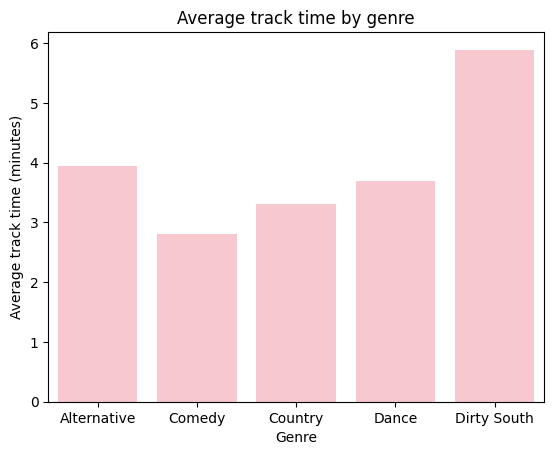

In [22]:
#plot tab1 average track time by genre
graph = sns.barplot(x='primaryGenreName', y='trackTimeMinutes', data=tab1, color= 'pink')
graph.set_title('Average track time by genre')
graph.set_xlabel('Genre')
graph.set_ylabel('Average track time (minutes)')
graph

In [9]:
# ================================================================================
# Step 7 - Artist power analysis
# ================================================================================
# Number of tracks per artist
track_counts = df.groupby("artistName")["trackName"].count()

# Average price per artist
avg_prices = df.groupby("artistName")["trackPrice"].mean()

# Combine both results into one table
tab2 = pd.concat([track_counts, avg_prices], axis=1)

# Rename columns for clarity
tab2.columns = ["track_count", "avg_price"]

# Convert artistName from index to column
tab2 = tab2.reset_index()

# Sort by track count
tab2 = tab2.sort_values(by="track_count", ascending=False)

display(tab2.head(10))

,artistName,track_count,avg_price
372,Wiz Khalifa,52,1.290
334,The Notorious B.I.G.,40,1.233
220,Meek Mill,36,1.290
112,Future,36,1.290
92,Eminem,34,1.223
114,G-Eazy,32,1.281
260,P!nk,29,1.290
368,Wale,24,1.290
276,Post Malone,23,1.290
358,"Tyler, The Creator",23,1.290


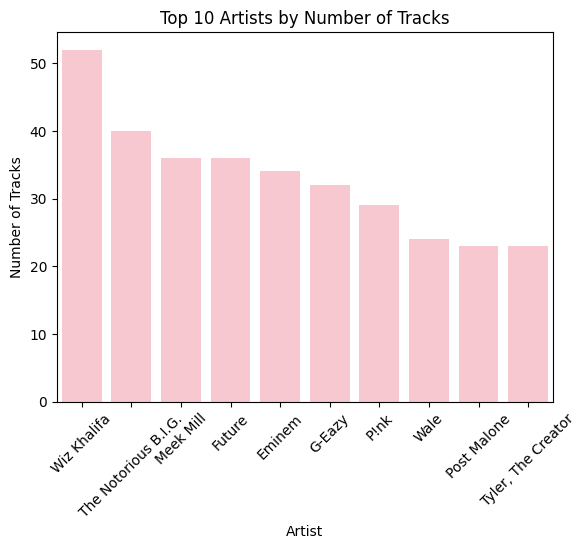

In [10]:
# Artist power analysis Graph
top_artists = tab2.head(10)

graph2 = sns.barplot(
    x="artistName",
    y="track_count",
    data=top_artists,
    color="pink"
)

graph2.set_title("Top 10 Artists by Number of Tracks")
graph2.set_xlabel("Artist")
graph2.set_ylabel("Number of Tracks")

plt.xticks(rotation=45)
plt.show()


### Data Manipulation

In [19]:
# ================================
# Step 8 - Track Explicitness
# ================================

# Convert explicit to 0/1
df['is_explicit'] = df['trackExplicitness'].apply(lambda x: 1 if x == 'explicit' else 0)

# Total number of songs in each genre
total_tracks = df.groupby('primaryGenreName')['trackId'].count().reset_index()
total_tracks.rename(columns={'trackId': 'total_tracks'}, inplace=True)

# The number of explicit tags for each genre
explicit_tracks = df.groupby('primaryGenreName')['is_explicit'].sum().reset_index()
explicit_tracks.rename(columns={'is_explicit': 'explicit_tracks'}, inplace=True)
tab3 = pd.merge(total_tracks, explicit_tracks, on='primaryGenreName')

# Sort by explicit rate
tab3['explicit_rate'] = tab3['explicit_tracks'] / tab3['total_tracks']
tab3 = tab3.sort_values(by='explicit_rate', ascending=False)

display(tab3)

,primaryGenreName,total_tracks,explicit_tracks,explicit_rate
1,Comedy,3,3,1.000
2,Country,18,18,1.000
5,Electronic,3,3,1.000
4,Dirty South,2,2,1.000
17,Singer/Songwriter,3,3,1.000
19,Urbano latino,2,2,1.000
10,Latin,1,1,1.000
9,Indie Rock,1,1,1.000
15,Rap,25,25,1.000
12,Musicals,9,9,1.000


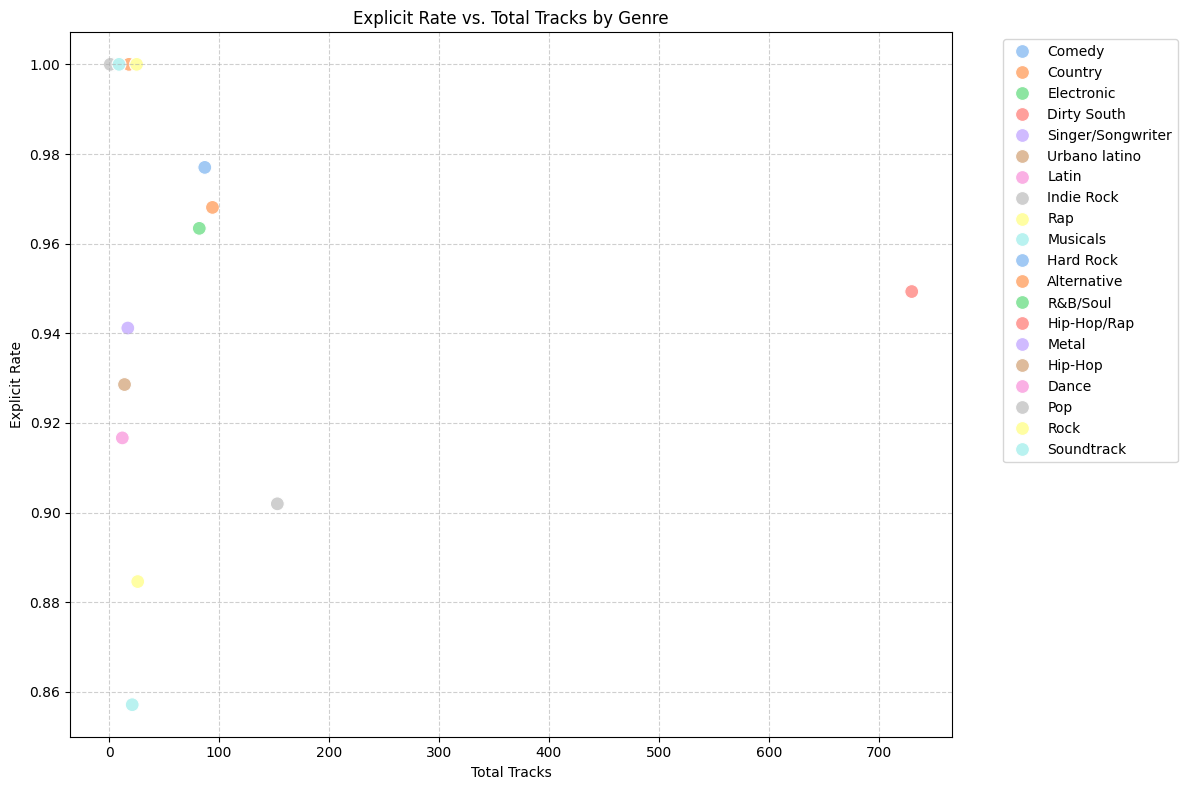

In [20]:
# ===================================
# Step 8 - Track Explicitness - Graph
# ===================================

plt.figure(figsize=(12, 8))
scatterplot = sns.scatterplot(
    x='total_tracks',
    y='explicit_rate',
    hue='primaryGenreName',
    data=tab3,
    s=100, # size of the points
    palette='pastel' # color palette
)

scatterplot.set_title('Explicit Rate vs. Total Tracks by Genre')
scatterplot.set_xlabel('Total Tracks')
scatterplot.set_ylabel('Explicit Rate')


plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside the plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [13]:
# ============================================================
# Step 9 - Actual vs expected track counts by album
# ============================================================

# Calculate the actual number of tracks
actual_tracks = df.groupby('collectionId')['trackId'].nunique().reset_index()
actual_tracks.rename(columns={'trackId': 'actual_tracks'}, inplace=True)

# Number of expected track
expected_tracks = df[['collectionId', 'collectionName', 'trackCount']].drop_duplicates()
expected_tracks.rename(columns={'trackCount': 'expected_tracks'}, inplace=True)

# Merging and calculating differences
album_check = pd.merge(actual_tracks, expected_tracks, on='collectionId')
album_check['difference'] = album_check['expected_tracks'] - album_check['actual_tracks']

tab4 = album_check[album_check['difference'] != 0]
tab4 = tab4.sort_values(by='difference',ascending=False)
display(tab4.head(10))

,collectionId,actual_tracks,collectionName,expected_tracks,difference
598,1667990565,4,One Thing At A Time,36,32
548,1434371867,2,A Star Is Born Soundtrack,34,32
593,1589139584,2,Red (Taylor's Version),30,28
179,303890724,1,Luniz - the Lost Tapes 2,27,26
206,342397437,1,The State vs. Radric Davis (Deluxe),27,26
431,978793524,1,Special Effects (Deluxe Version),26,25
340,664657927,1,Something Else (All Access Edition),26,25
508,1244229844,1,Grateful,23,22
595,1622045624,1,Un Verano Sin Ti,23,22
363,778831487,1,Hello Nasty,22,21


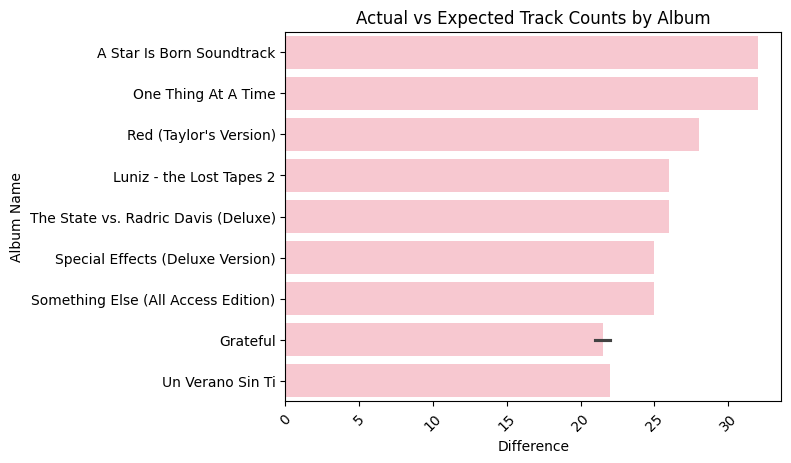

In [15]:
# ===========================================================
# Step 9 - Actual vs expected track counts by album- Graph
# ===========================================================
import matplotlib.pyplot as plt
import seaborn as sns

plot_data = tab4.copy()
plot_data['abs_diff']=plot_data['difference'].abs()
plot_data = plot_data.sort_values(by='abs_diff', ascending=False).head(10)

graph4 = sns.barplot(x='difference', y='collectionName', data=plot_data, color='pink')

graph4.set_title('Actual vs Expected Track Counts by Album')
graph4.set_xlabel('Difference')
graph4.set_ylabel('Album Name')

plt.xticks(rotation=45)
plt.show()

In [16]:
# ===================================================
# Step 10 - Album price vs total track price
# ===================================================

# Sum of individual track prices by album
track_sum = df.groupby('collectionId')['trackPrice'].sum().reset_index()
track_sum.rename(columns={'trackPrice': 'sum_track_price'}, inplace=True)

# Get album name and album price
album_price = df[['collectionId', 'collectionName', 'collectionPrice']].drop_duplicates()

# Merge the two tables
price_check = pd.merge(track_sum, album_price, on='collectionId')

# Calculate difference
price_check['price_difference'] = price_check['sum_track_price'] - price_check['collectionPrice']

# Label the better option
price_check['better_option'] = 'Same price'
price_check.loc[price_check['price_difference'] > 0, 'better_option'] = 'Album is cheaper'
price_check.loc[price_check['price_difference'] < 0, 'better_option'] = 'Tracks are cheaper'

display(price_check.head(10))

,collectionId,sum_track_price,collectionName,collectionPrice,price_difference,better_option
0,1264578,2.580,Under Construction,9.990,-7.410,Tracks are cheaper
1,5239273,2.580,Kamikaze,9.990,-7.410,Tracks are cheaper
2,19440815,1.290,Crime Mob,9.990,-8.700,Tracks are cheaper
3,21825130,1.290,Let's Go - Single,1.290,0.000,Same price
4,27295695,2.580,Thug Matrimony: Married to the Streets,9.990,-7.410,Tracks are cheaper
5,28518205,1.290,Real Talk,9.990,-8.700,Tracks are cheaper
6,32990861,1.290,Nasty Confessions,-1.000,2.290,Album is cheaper
7,56218556,2.580,Who Is Mike Jones?,9.990,-7.410,Tracks are cheaper
8,63490904,2.580,Bluestars,10.990,-8.410,Tracks are cheaper
9,63816391,1.290,In Love and Death,9.990,-8.700,Tracks are cheaper


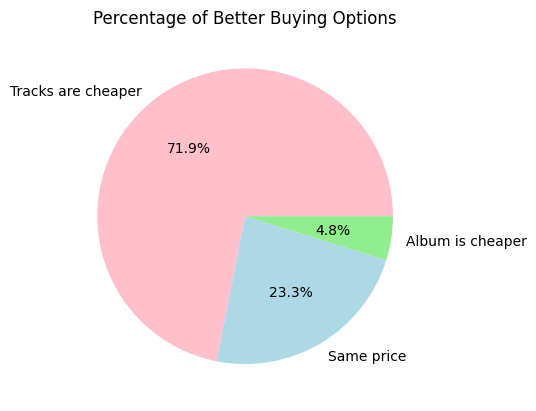

In [17]:
# ===================================================
# Step 10 - Album price vs total track price- Graph
# ===================================================

Counts=price_check['better_option'].value_counts()

plt.pie(Counts, labels=Counts.index,autopct='%1.1f%%',
        colors=['pink', 'lightblue', 'lightgreen'])


plt.title('Percentage of Better Buying Options')
plt.show()
